In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [12]:
train_data = pd.read_csv('mnist_train.csv')
test_data = pd.read_csv('mnist_test.csv')

y_train_raw = train_data.iloc[:, 0].values.reshape(-1, 1)
X_train_raw = train_data.iloc[:, 1:].values

y_test_raw = test_data.iloc[:, 0].values.reshape(-1, 1)
X_test_raw = test_data.iloc[:, 1:].values

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw).T
X_test = scaler.transform(X_test_raw).T

encoder = OneHotEncoder(sparse_output=False)
Y_train_encoded = encoder.fit_transform(y_train_raw).T
Y_test_encoded = encoder.transform(y_test_raw).T

Y_train = y_train_raw.flatten()
Y_test = y_test_raw.flatten()

print(f"X_train shape: {X_train.shape}")
print(f"Y_train_encoded shape: {Y_train_encoded.shape}")

X_train shape: (784, 60000)
Y_train_encoded shape: (10, 60000)


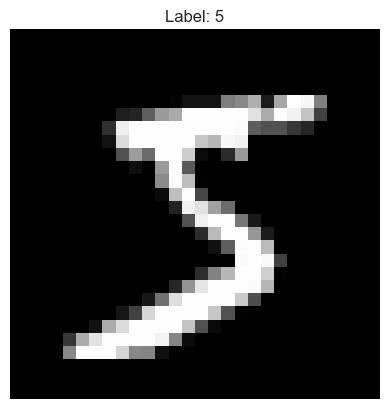

In [13]:
def visualize_digit(X, Y, index):
    current_image = X[:, index].reshape((28, 28))
    label = Y[index]

    plt.imshow(current_image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

visualize_digit(X_train, Y_train, 0)

In [14]:
def init_params():
    W1 = np.random.randn(128, 784) * np.sqrt(2. / 784)
    b1 = np.zeros((128, 1))

    W2 = np.random.randn(10, 128) * np.sqrt(1. / 128)
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=0)
    A = np.exp(Z_shifted) / np.sum(np.exp(Z_shifted), axis=0)
    return A

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def deriv_ReLU(Z):
    return Z > 0

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y_encoded):
    m = X.shape[1]

    dZ2 = A2 - Y_encoded
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [15]:
def get_predictions(A2):
    return np.argmax(A2, axis=0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def compute_loss(A2, Y_encoded):
    m = Y_encoded.shape[1]
    log_probs = np.multiply(np.log(A2 + 1e-8), Y_encoded)
    cost = -1/m * np.sum(log_probs)
    return cost

Iteration: 0 | Loss: 2.4139 | Accuracy: 0.0864
Iteration: 50 | Loss: 0.7630 | Accuracy: 0.8354
Iteration: 100 | Loss: 0.5069 | Accuracy: 0.8730
Iteration: 150 | Loss: 0.4251 | Accuracy: 0.8870
Iteration: 200 | Loss: 0.3831 | Accuracy: 0.8955
Iteration: 250 | Loss: 0.3563 | Accuracy: 0.9014
Iteration: 300 | Loss: 0.3369 | Accuracy: 0.9062
Iteration: 350 | Loss: 0.3217 | Accuracy: 0.9101
Iteration: 400 | Loss: 0.3092 | Accuracy: 0.9135
Iteration: 450 | Loss: 0.2984 | Accuracy: 0.9162


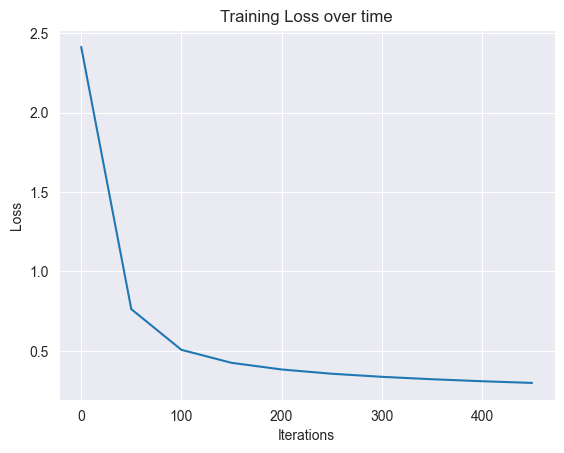

In [16]:
def gradient_descent(X, Y, Y_encoded, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    loss_history = []

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)

        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y_encoded)

        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        if i % 50 == 0:
            predictions = get_predictions(A2)
            accuracy = get_accuracy(predictions, Y)
            loss = compute_loss(A2, Y_encoded)
            loss_history.append(loss)
            print(f"Iteration: {i} | Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

    return W1, b1, W2, b2, loss_history

W1, b1, W2, b2, loss_history = gradient_descent(X_train, Y_train, Y_train_encoded, alpha=0.1, iterations=500)

plt.plot(range(0, 500, 50), loss_history)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss over time')
plt.show()

Final Accuracy on Test Set: 92.2200%
Prediction:  0
Actual Label:  0


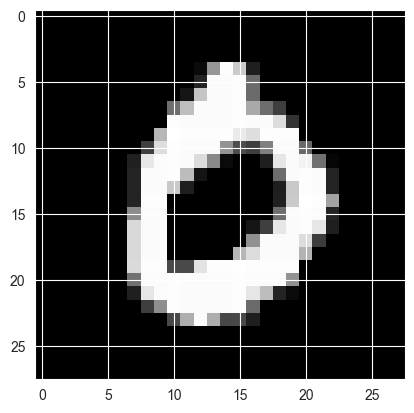

Prediction:  4
Actual Label:  4


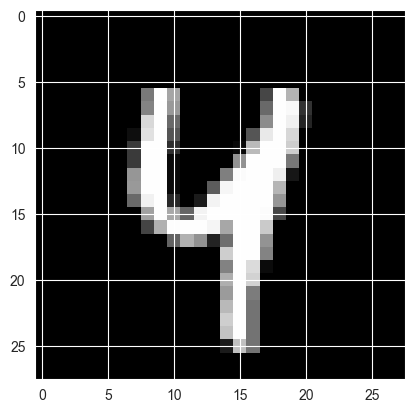

In [24]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

test_preds = make_predictions(X_test, W1, b1, W2, b2)
test_acc = get_accuracy(test_preds, Y_test) * 100
print(f"Final Accuracy on Test Set: {test_acc:.4f}%")

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_test[:, index, None]
    prediction = make_predictions(current_image, W1, b1, W2, b2)
    label = Y_test[index]

    print("Prediction: ", prediction[0])
    print("Actual Label: ", label)

    img_plot = current_image.reshape((28, 28)) * 255
    plt.imshow(img_plot, cmap='gray')
    plt.show()

test_prediction(3, W1, b1, W2, b2)
test_prediction(42, W1, b1, W2, b2)